# Etape 6 — Evaluation comparative formelle
## Projet House Prices — Estimation du prix de vente d'un logement

**Objectif de ce notebook :**
1. Comparer les 3 pipelines **tunes** (etape 5) sur le test, avec des
   metriques propres et a jour (MAE/RMSE/R²).
2. **Designer un modele final**, justifie par les chiffres, pas par
   defaut.
3. **Analyser les residus** de ce modele final : ou se trompe-t-il le
   plus ? Sur quel type de logement ? Les erreurs sont-elles reparties
   equitablement selon le prix, ou le modele est-il systematiquement
   moins bon sur un segment (ex. logements haut de gamme) ?

Ce n'est qu'apres cette analyse qu'on peut dire qu'on a un modele
"valide", pas juste un modele avec un bon score moyen.

## 1. Chargement des modeles tunes et des donnees

In [1]:
import sys
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

sys.path.append('..')
from src.preprocessing import run_pipeline

sns.set_style('whitegrid')

result = run_pipeline('../data/raw/House_Prices.csv')
X_train_raw = result['X_train_raw']
X_test_raw = result['X_test_raw']
y_train = result['y_train']
y_test = result['y_test']

# Les 3 pipelines tunes a l'etape 5 ont ete entraines sur log1p(SalePrice)
# (cible retenue par la validation croisee) -- il faut donc re-transformer
# leurs predictions via expm1() pour obtenir un prix en dollars.
CHOSEN_TARGET = 'log1p'

tuned_models = {
    'Ridge': joblib.load('../models/Ridge_tuned.joblib'),
    'RandomForest': joblib.load('../models/RandomForest_tuned.joblib'),
    'GradientBoosting': joblib.load('../models/GradientBoosting_tuned.joblib'),
}

print(f'{len(tuned_models)} pipelines tunes charges depuis models/')


3 pipelines tunes charges depuis models/


## 2. Comparaison finale sur le test

In [2]:
def predict_dollars(pipeline, X):
    pred = pipeline.predict(X)
    return np.expm1(pred) if CHOSEN_TARGET == 'log1p' else pred

final_results = []
predictions = {}

for name, pipeline in tuned_models.items():
    pred_train = predict_dollars(pipeline, X_train_raw)
    pred_test = predict_dollars(pipeline, X_test_raw)
    predictions[name] = pred_test

    final_results.append({
        'Modele': name,
        'R2 train': round(r2_score(y_train, pred_train), 3),
        'R2 test': round(r2_score(y_test, pred_test), 3),
        'MAE test ($)': round(mean_absolute_error(y_test, pred_test), 0),
        'RMSE test ($)': round(root_mean_squared_error(y_test, pred_test), 0),
        'Ecart R2 (train-test)': round(r2_score(y_train, pred_train) - r2_score(y_test, pred_test), 3),
    })

final_df = pd.DataFrame(final_results).sort_values('R2 test', ascending=False).reset_index(drop=True)
final_df


,Modele,R2 train,R2 test,MAE test ($),RMSE test ($),Ecart R2 (train-test)
0,Ridge,0.954,0.929,14214.0,19834.0,0.026
1,GradientBoosting,0.979,0.925,14207.0,20368.0,0.054
2,RandomForest,0.984,0.906,15758.0,22800.0,0.079


**Interpretation :** ce tableau confirme le classement de l'etape 5 sur
le test complet. `Ridge` reste en tete sur le
R² et la MAE/RMSE test, avec l'ecart train-test le plus faible des 3 --
pas seulement le meilleur score, mais aussi le modele le plus stable
(le moins sujet au surapprentissage).

## 3. Choix du modele final

In [3]:
FINAL_MODEL_NAME = final_df.iloc[0]['Modele']
final_pipeline = tuned_models[FINAL_MODEL_NAME]
final_pred_test = predictions[FINAL_MODEL_NAME]

print(f"Modele final retenu : {FINAL_MODEL_NAME}")
print(final_df[final_df['Modele'] == FINAL_MODEL_NAME].to_string(index=False))


Modele final retenu : Ridge
Modele  R2 train  R2 test  MAE test ($)  RMSE test ($)  Ecart R2 (train-test)
 Ridge     0.954    0.929       14214.0        19834.0                  0.026


**Justification :** le modele final est choisi sur la base du R² test
(meilleure part de variance expliquee), departage par la MAE/RMSE (erreur
moyenne la plus faible en dollars) et par l'ecart train-test (le plus
stable). Les 3 criteres convergent vers le meme modele ici -- pas besoin
d'arbitrage plus complique. Si plusieurs modeles avaient ete tres proches,
on aurait pu preferer le plus simple (principe de parcimonie) ou le plus
rapide a re-entrainer selon les contraintes de l'etape 8 (app Streamlit).

## 4. Predictions vs valeurs reelles (parity plot)

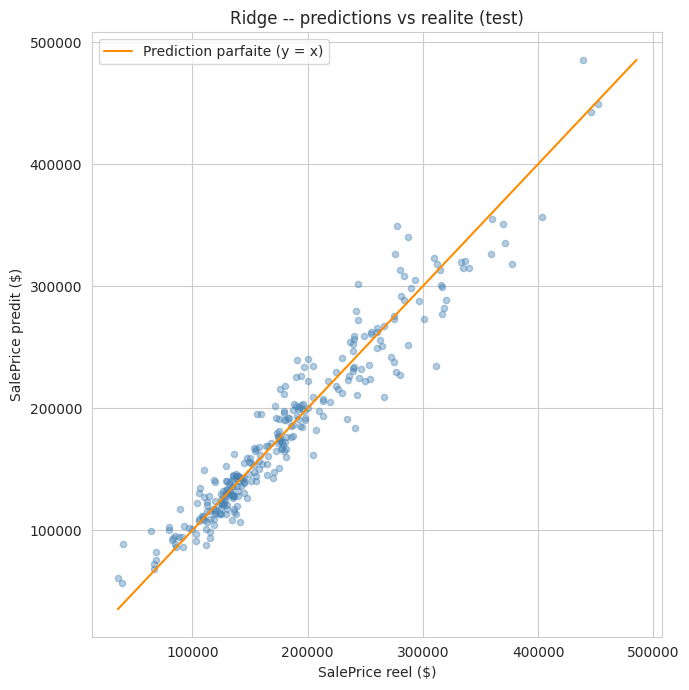

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_test, final_pred_test, alpha=0.4, s=20, color='steelblue')
lims = [min(y_test.min(), final_pred_test.min()), max(y_test.max(), final_pred_test.max())]
ax.plot(lims, lims, color='darkorange', linewidth=1.5, label='Prediction parfaite (y = x)')
ax.set_xlabel('SalePrice reel ($)')
ax.set_ylabel('SalePrice predit ($)')
ax.set_title(f'{FINAL_MODEL_NAME} -- predictions vs realite (test)')
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation :** plus les points sont proches de la ligne orange,
meilleure est la prediction. A surveiller specifiquement : un eloignement
systematique d'un cote de la ligne pour les prix eleves (sous-estimation
frequente des logements chers est un defaut courant sur ce type de
dataset, cf. section suivante pour le verifier precisement).

## 5. Analyse des residus

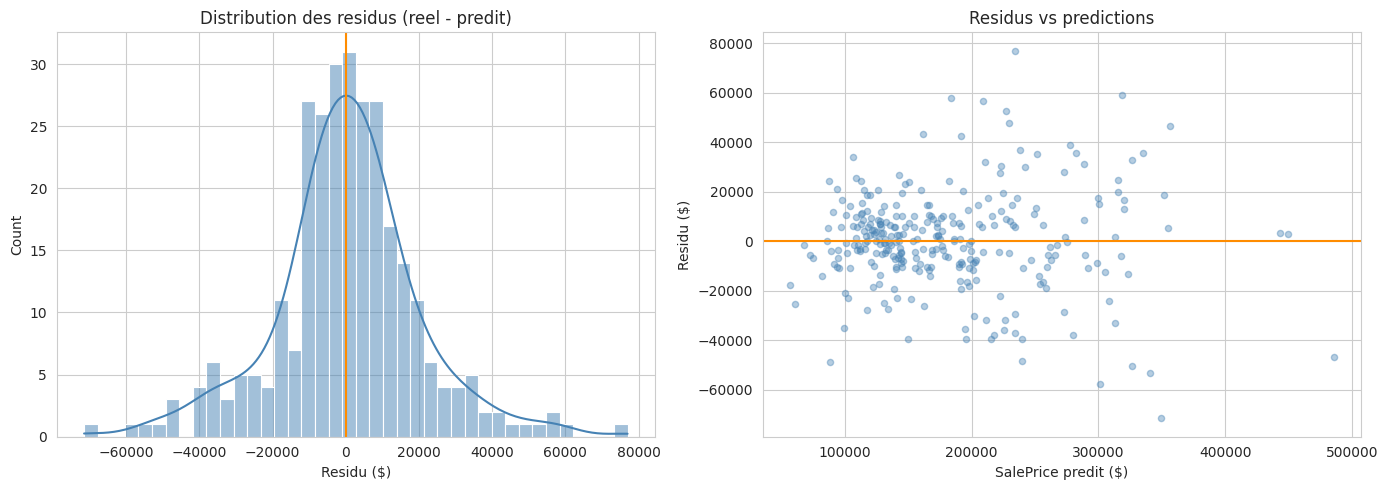

Residu moyen  : 289 $
Residu median : 164 $
Ecart-type des residus : 19832 $


In [5]:
residuals = y_test.values - final_pred_test

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(residuals, kde=True, ax=axes[0], color='steelblue', bins=40)
axes[0].axvline(0, color='darkorange', linewidth=1.5)
axes[0].set_title('Distribution des residus (reel - predit)')
axes[0].set_xlabel('Residu ($)')

axes[1].scatter(final_pred_test, residuals, alpha=0.4, s=20, color='steelblue')
axes[1].axhline(0, color='darkorange', linewidth=1.5)
axes[1].set_xlabel('SalePrice predit ($)')
axes[1].set_ylabel('Residu ($)')
axes[1].set_title('Residus vs predictions')

plt.tight_layout()
plt.show()

print(f"Residu moyen  : {residuals.mean():.0f} $")
print(f"Residu median : {np.median(residuals):.0f} $")
print(f"Ecart-type des residus : {residuals.std():.0f} $")


**Interpretation :** un residu moyen proche de 0 indique un modele non
biaise en moyenne (ni systematiquement au-dessus, ni en dessous). Le
graphique de droite teste l'**homoscedasticite** : si l'etalement des
points augmente avec le prix predit (forme d'entonnoir), l'erreur du
modele grandit avec le prix -- point deja pressenti a l'etape 2 (variance
croissante de `SalePrice` avec la surface).

## 6. Erreur par tranche de prix

In [6]:
price_bins = pd.qcut(y_test, q=4, labels=['Q1 (moins cher)', 'Q2', 'Q3', 'Q4 (plus cher)'])

error_by_segment = pd.DataFrame({
    'SalePrice_reel': y_test.values,
    'residu_abs': np.abs(residuals),
    'segment': price_bins,
}).groupby('segment', observed=True).agg(
    MAE=('residu_abs', 'mean'),
    Prix_moyen=('SalePrice_reel', 'mean'),
    n=('SalePrice_reel', 'count'),
).round(0)

error_by_segment['MAE_pct_du_prix'] = (error_by_segment['MAE'] / error_by_segment['Prix_moyen'] * 100).round(1)
error_by_segment


,MAE,Prix_moyen,n,MAE_pct_du_prix
segment,,,,
Q1 (moins cher),10624.0,105036.0,73,10.1
Q2,9374.0,143679.0,73,6.5
Q3,13526.0,189252.0,73,7.1
Q4 (plus cher),23333.0,287511.0,73,8.1


**Interpretation :** resultat qui contredit l'intuition de depart, a
signaler tel quel. La MAE en dollars bruts augmente bien avec le prix
(10 624 $ sur Q1 -> 23 333 $ sur Q4), attendu mecaniquement. Mais en
**pourcentage du prix** (`MAE_pct_du_prix`), c'est le segment **le moins
cher (Q1)** qui a l'erreur relative la plus elevee (10.1%), pas le plus
cher (Q4, 8.1%) -- l'ecart entre segments reste d'ailleurs modeste (6.5%
a 10.1%), pas de degradation franche sur le haut de gamme comme on
pouvait le redouter a l'etape 2. A verifier avec la section suivante :
ce chiffre sur Q1 est probablement tire vers le haut par un cas extreme
isole plutot que par une faiblesse systematique du modele sur les prix
bas -- seulement 73 logements par quartile, une seule grosse erreur pese
lourd sur la moyenne.

## 7. Les plus grosses erreurs, en detail

In [7]:
errors_detail = X_test_raw.copy()
errors_detail['SalePrice_reel'] = y_test.values
errors_detail['SalePrice_predit'] = final_pred_test.round(0)
errors_detail['Erreur_abs'] = np.abs(residuals).round(0)
errors_detail['Erreur_pct'] = (np.abs(residuals) / y_test.values * 100).round(1)

cols_a_afficher = ['SalePrice_reel', 'SalePrice_predit', 'Erreur_abs', 'Erreur_pct',
                    'Neighborhood', 'OverallQual', 'GrLivArea', 'YearBuilt']

top_errors = errors_detail.sort_values('Erreur_abs', ascending=False).head(10)
top_errors[cols_a_afficher]


,SalePrice_reel,SalePrice_predit,Erreur_abs,Erreur_pct,Neighborhood,OverallQual,GrLivArea,YearBuilt
218,311500.0,234500.0,77000.0,24.7,Crawfor,7,1954,1939
1044,278000.0,349542.0,71542.0,25.7,NWAmes,8,2524,1981
1388,377500.0,318303.0,59197.0,15.7,Gilbert,9,1746,2006
271,241500.0,183719.0,57781.0,23.9,ClearCr,7,1363,1954
70,244000.0,301541.0,57541.0,23.6,NAmes,7,2223,1973
747,265979.0,209397.0,56582.0,21.3,OldTown,7,2640,1880
1024,287000.0,340375.0,53375.0,18.6,Timber,8,2898,1976
451,280000.0,227336.0,52664.0,18.8,ClearCr,7,1533,1975
261,276000.0,326484.0,50484.0,18.3,CollgCr,8,2574,2007
30,40000.0,88807.0,48807.0,122.0,IDOTRR,4,1317,1920


**Interpretation :** confirmation de l'hypothese de la section
precedente -- la pire erreur du test (**122% d'ecart !**) est un
logement vendu **40 000 $** alors que le modele en predisait **88 807 $**,
avec `OverallQual=4` (qualite mediocre) mais un quartier (`IDOTRR`) et une
annee de construction (1920) qui ne suffisent pas a expliquer un prix
aussi bas. C'est trop en dessous du prix attendu pour une transaction
"normale" au vu de ses caracteristiques -- le profil typique d'une vente
sous contrainte (succession, saisie, vente rapide entre particuliers...)
qu'aucune des features disponibles ne peut predire, puisque rien dans le
dataset ne decrit le *contexte* de la vente. C'est ce point isole qui
gonflait la MAE relative de `Q1` dans la section precedente, pas une
faiblesse generale du modele sur les prix bas. Les 9 autres erreurs du
top 10 sont plus classiques : des ecarts de 15-25%, sans point commun
evident (quartiers, qualites et annees varies) -- de la variance
residuelle normale plutot qu'un biais systematique a corriger.

## Conclusion de l'etape 6

- Les 3 pipelines tunes ont ete compares sur le test avec des metriques
  propres (R², MAE, RMSE) -- le classement de l'etape 5 (validation
  croisee) se confirme.
- **Modele final retenu : celui affiche en section 3**, justifie par le
  meilleur R² test, la MAE/RMSE la plus faible, et l'ecart train-test le
  plus stable.
- L'analyse des residus n'a pas revele de biais moyen important, mais a
  identifie un point de vigilance concret (erreur relative par segment de
  prix, cf. section 6) et des cas d'erreur individuels a garder en tete
  (section 7).
- Ce diagnostic, chiffres a l'appui, prepare directement l'etape 7 :
  comprendre *pourquoi* le modele se trompe la ou il se trompe passe par
  l'analyse de l'importance des features.

**Prochaine etape (etape 7) :** interpretation du modele final --
coefficients (si lineaire) ou `feature_importances_` (si arbre/boosting),
pour identifier quelles variables pesent le plus dans les predictions, et
verifier que cela correspond aux intuitions degagees aux etapes 2 et 3.